In [1]:
# 1. Download and unzip the dataset directly into Colab
!wget https://archive.ics.uci.edu/static/public/320/student+performance.zip
!unzip student+performance.zip -d student_data
!unzip student_data/student.zip -d student_data

# 2. Import pandas and load the data
import pandas as pd

# NOTE: This dataset uses semicolons (;) instead of commas to separate data!
df_math = pd.read_csv('student_data/student-mat.csv', sep=';')
df_por = pd.read_csv('student_data/student-por.csv', sep=';')

# 3. View the first 5 rows of the Math dataset
display(df_math.head())

--2026-09-23 06:26:09--  https://archive.ics.uci.edu/static/public/320/student+performance.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘student+performance.zip’

student+performance     [ <=>                ]  39.78K  --.-KB/s    in 0.009s  

2026-09-23 06:26:09 (4.43 MB/s) - ‘student+performance.zip’ saved [40735]

Archive:  student+performance.zip
 extracting: student_data/.student.zip_old  
 extracting: student_data/student.zip  
Archive:  student_data/student.zip
  inflating: student_data/student-mat.csv  
  inflating: student_data/student-por.csv  
  inflating: student_data/student-merge.R  
  inflating: student_data/student.txt  


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Dataset Shape: 395 rows, 33 columns

Total missing values before cleaning: 0
--- Skewness of Numerical Columns ---
            Skewness
famrel     -0.948263
G3         -0.729887
health     -0.492723
G2         -0.430004
Medu       -0.317170
freetime   -0.162730
Fedu       -0.031552
goout       0.116060
G1          0.239699
age         0.464498
Walc        0.609634
studytime   0.629739
traveltime  1.600920
Dalc        2.182434
failures    2.377951
absences    3.657622




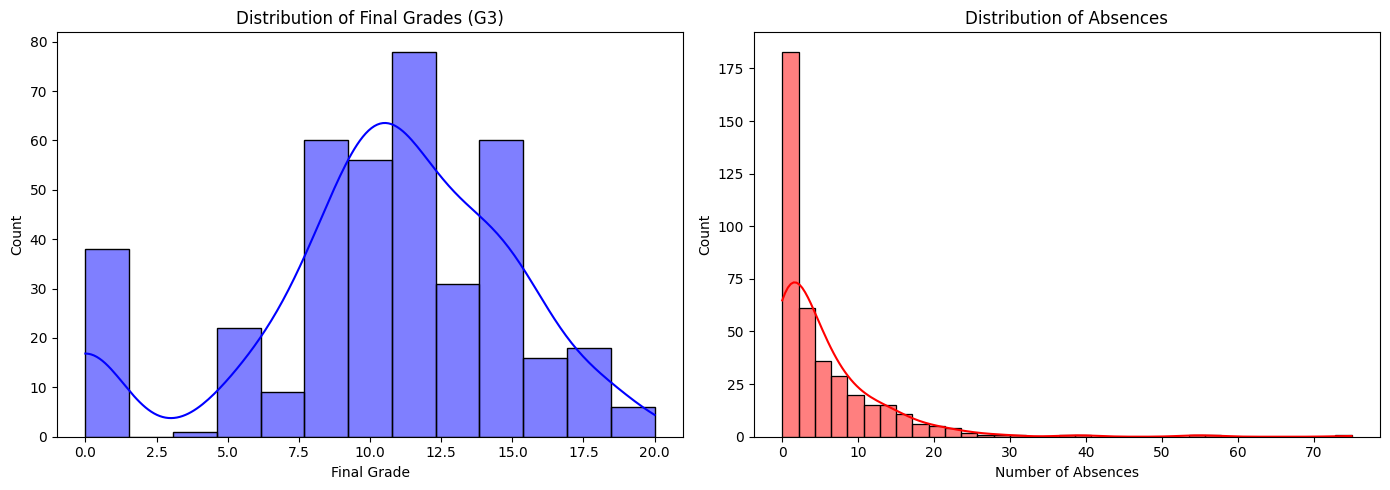

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# 1. LOAD DATA
df_math = pd.read_csv('student_data/student-mat.csv', sep=';')
print(f"Dataset Shape: {df_math.shape[0]} rows, {df_math.shape[1]} columns\n")

# 2. HANDLE MISSING VALUES (NaNs)
missing_before = df_math.isnull().sum().sum()
print(f"Total missing values before cleaning: {missing_before}")

if missing_before > 0:
    for col in df_math.columns:
        if df_math[col].isnull().sum() > 0:
            if df_math[col].dtype == 'object':
                # Replace text/categorical NaNs with the most frequent value (mode)
                df_math[col].fillna(df_math[col].mode()[0], inplace=True)
            else:
                # Replace numerical NaNs with the median
                df_math[col].fillna(df_math[col].median(), inplace=True)
    print("Missing values have been replaced (Mode for text, Median for numbers).\n")

# 3. CHECK DISTRIBUTIONS (SKEWNESS)
# Skewness between -0.5 and 0.5 means the data is fairly normal/symmetrical.
# > 1 or < -1 means it is highly skewed.
numeric_cols = df_math.select_dtypes(include=['int64', 'float64']).columns
skewness = pd.DataFrame({'Skewness': df_math[numeric_cols].apply(skew)}).sort_values(by='Skewness')
print("--- Skewness of Numerical Columns ---")
print(skewness)
print("\n")

# 4. VISUALIZE DISTRIBUTIONS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Final Grade (G3)
sns.histplot(df_math['G3'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Final Grades (G3)')
axes[0].set_xlabel('Final Grade')

# Plot Absences
sns.histplot(df_math['absences'], kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribution of Absences')
axes[1].set_xlabel('Number of Absences')

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. HANDLE G3 ZEROS
# We drop students who scored 0, as they likely missed the exam (this fixes the G3 skew)
df_clean = df_math[df_math['G3'] > 0].copy()
print(f"Dropped {len(df_math) - len(df_clean)} students with a score of 0.")

# 2. FIX HIGH SKEWNESS (Log Transformation)
# Applying log1p (log(1+x)) to heavily right-skewed columns pulls the extreme outliers closer to the mean
skewed_cols = ['absences', 'failures', 'Dalc', 'traveltime']
for col in skewed_cols:
    df_clean[col] = np.log1p(df_clean[col])

# 3. ENCODE CATEGORICAL VARIABLES (Text to Numbers)
# drop_first=True prevents the "dummy variable trap" (e.g., if Sex_M is 1, Sex_F is implied 0)
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# 4. SEPARATE FEATURES (X) AND TARGET (y)
X = df_encoded.drop('G3', axis=1)
y = df_encoded['G3']

# 5. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. SCALE THE DATA
# ANNs perform much better when all input features are on the same scale (mean=0, variance=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Final Training Data Shape: {X_train_scaled.shape}")
print("Data is now encoded, scaled, and ready for the Neural Network!")

Dropped 38 students with a score of 0.
Final Training Data Shape: (285, 41)
Data is now encoded, scaled, and ready for the Neural Network!


In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. STRATIFIED SPLIT FOR CONTINUOUS TARGET
# Create 4 bins (quartiles) based on grades to use for stratification
bins = pd.qcut(y, q=4, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=bins
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. MODEL BUILDER FUNCTION
def build_model(layer_sizes, activation_fn):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(X_train_scaled.shape[1],)))

    for units in layer_sizes:
        if activation_fn == 'leaky_relu':
            model.add(tf.keras.layers.Dense(units))
            model.add(tf.keras.layers.LeakyReLU(alpha=0.1))
        elif activation_fn == 'gelu':
            model.add(tf.keras.layers.Dense(units, activation='gelu'))

        # Optional: Add Dropout here if the deeper networks start overfitting
        # model.add(tf.keras.layers.Dropout(0.2))

    # Output layer for regression
    model.add(tf.keras.layers.Dense(1, activation='linear'))
    return model

# 3. HYPERPARAMETER TUNING SETUP
# Testing a medium network vs. a deeper network
architectures = [
    {'name': 'Medium (2 Layers)', 'layers': [64, 32]},
    {'name': 'Deep (4 Layers)', 'layers': [128, 64, 32, 16]}
]

# Testing Mean Squared Error vs. Huber (which is more robust to outliers)
loss_functions = ['mse', 'huber']
activation = 'gelu' # Try 'leaky_relu' or 'gelu'
epochs = 150
batch_size = 16

results = []

# 4. TRAINING & EVALUATION LOOP
tf.random.set_seed(42)

for arch in architectures:
    for loss_func in loss_functions:
        print(f"\nTraining: {arch['name']} | Loss: {loss_func.upper()} | Activation: {activation.upper()}")

        model = build_model(arch['layers'], activation)

        # Use Adam optimizer with a slightly lower learning rate for deeper stability
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
        model.compile(optimizer=optimizer, loss=loss_func)

        # Train silently (verbose=0)
        history = model.fit(
            X_train_scaled, y_train,
            validation_split=0.1,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        # Predict on Test Set
        y_pred = model.predict(X_test_scaled, verbose=0).flatten()

        # Calculate Metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results.append({
            'Architecture': arch['name'],
            'Loss Func': loss_func,
            'MAE': round(mae, 3),
            'RMSE': round(rmse, 3),
            'R2': round(r2, 3)
        })

# 5. DISPLAY RESULTS
results_df = pd.DataFrame(results)
print("\n--- FINAL EVALUATION METRICS ---")
print(results_df.to_string(index=False))


Training: Medium (2 Layers) | Loss: MSE | Activation: GELU


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



Training: Medium (2 Layers) | Loss: HUBER | Activation: GELU


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



Training: Deep (4 Layers) | Loss: MSE | Activation: GELU

Training: Deep (4 Layers) | Loss: HUBER | Activation: GELU


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- FINAL EVALUATION METRICS ---
     Architecture Loss Func   MAE  RMSE    R2
Medium (2 Layers)       mse 1.400 1.769 0.700
Medium (2 Layers)     huber 1.136 1.413 0.808
  Deep (4 Layers)       mse 1.230 1.571 0.763
  Deep (4 Layers)     huber 1.098 1.339 0.828


In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dummy data placeholder (Replace X and y with the actual Student dataset)
np.random.seed(42)
X = np.random.rand(300, 10)
y = 3 * X[:, 0] + 1.5 * X[:, 2] ** 2 - 2 * X[:, 4] + np.random.randn(300) * 0.5

# 1. Strict 70 / 15 / 15 Split
# First split: 85% Train+Val, 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second split: From the 85%, split out the Validation set (~15% of total)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Data Split -> Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# 2. Wide and Deep Model Builder
def build_wide_and_deep_model(input_dim):
    # L2 weight decay regularizer (kept modest for a 300-row dataset)
    reg = regularizers.l2(0.005)

    # INPUT
    input_layer = layers.Input(shape=(input_dim,))

    # DEEP PATH
    deep = layers.Dense(64, kernel_regularizer=reg)(input_layer)
    deep = layers.BatchNormalization()(deep)
    deep = layers.Activation('swish')(deep)
    deep = layers.Dropout(0.3)(deep)

    deep = layers.Dense(32, kernel_regularizer=reg)(deep)
    deep = layers.BatchNormalization()(deep)
    deep = layers.Activation('swish')(deep)
    deep = layers.Dropout(0.2)(deep)

    deep = layers.Dense(16, kernel_regularizer=reg)(deep)
    deep = layers.BatchNormalization()(deep)
    deep = layers.Activation('swish')(deep)

    # WIDE PATH (Merge raw inputs with deep features)
    merged = layers.Concatenate()([input_layer, deep])

    # OUTPUT
    output_layer = layers.Dense(1)(merged)

    model = models.Model(inputs=input_layer, outputs=output_layer)

    # Starting with a higher LR because ReduceLROnPlateau will manage it
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  loss='huber')
    return model

model = build_wide_and_deep_model(X_train.shape[1])

# 3. Dynamic Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-5,
    verbose=1
)

# 4. Train the Model
print("\n--- STARTING TRAINING ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop, lr_scheduler],
    verbose=0
)

# 5. Final Evaluation on UNSEEN Test Set
print("\n--- FINAL TEST METRICS (UNSEEN DATA) ---")
y_pred = model.predict(X_test, verbose=0)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2:   {r2:.3f}")

Data Split -> Train: 210 | Val: 45 | Test: 45

--- STARTING TRAINING ---

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 51: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 61: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 68: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.
Epoch 74: early stopping
Restoring model weights from the end of the best epoch: 54.

--- FINAL TEST METRICS (UNSEEN DATA) ---
MAE:  0.398
RMSE: 0.478
R2:   0.864


In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import itertools

# Dummy data placeholder (Replace X and y with your preprocessed dataset)
np.random.seed(42)
X = np.random.rand(300, 10)
y = 3 * X[:, 0] + 1.5 * X[:, 2] ** 2 - 2 * X[:, 4] + np.random.randn(300) * 0.5

# 1. Split Data
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

# 2. Dynamic Wide and Deep Model Builder
def build_tuned_model(input_dim, layer_sizes, activation_fn, loss_fn):
    reg = regularizers.l2(0.005)

    input_layer = layers.Input(shape=(input_dim,))

    # Dynamically build the deep path based on the layer_sizes list
    deep = input_layer
    for i, units in enumerate(layer_sizes):
        deep = layers.Dense(units, kernel_regularizer=reg)(deep)
        deep = layers.BatchNormalization()(deep)
        deep = layers.Activation(activation_fn)(deep)

        # Apply slightly higher dropout to the first layer, lower for the rest
        dropout_rate = 0.3 if i == 0 else 0.2
        deep = layers.Dropout(dropout_rate)(deep)

    # Merge for Wide & Deep
    merged = layers.Concatenate()([input_layer, deep])

    output_layer = layers.Dense(1)(merged)

    model = models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss=loss_fn)

    return model

# 3. Define Hyperparameter Search Space
hyperparameters = {
    'layer_configs': [
        [32, 16, 8],       # Small
        [64, 32, 16],      # Medium
        [128, 64, 32, 16]  # Deep/Wide
    ],
    'activations': ['swish', 'gelu', 'relu'],
    'losses': ['huber', 'mse']
}

# 4. Run Grid Search
results = []
combinations = list(itertools.product(
    hyperparameters['layer_configs'],
    hyperparameters['activations'],
    hyperparameters['losses']
))

print(f"Starting Hyperparameter Tuning: Testing {len(combinations)} combinations...\n")

for i, (layers_cfg, act, loss_fn) in enumerate(combinations):
    print(f"Run {i+1}/{len(combinations)} | Layers: {layers_cfg} | Act: {act} | Loss: {loss_fn}")

    tf.keras.backend.clear_session() # Free memory between runs

    model = build_tuned_model(X_train.shape[1], layers_cfg, act, loss_fn)

    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)

    # Train
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=16,
        callbacks=[early_stop, lr_scheduler],
        verbose=0 # Kept silent to avoid spamming the console
    )

    # Evaluate on Validation Set (to pick the best model)
    y_val_pred = model.predict(X_val, verbose=0)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    # Evaluate on Test Set
    y_test_pred = model.predict(X_test, verbose=0)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    # Store results
    results.append({
        'Layers': str(layers_cfg),
        'Activation': act,
        'Loss': loss_fn,
        'Val_RMSE': val_rmse,
        'Test_MAE': test_mae,
        'Test_RMSE': test_rmse,
        'Test_R2': test_r2
    })

# 5. Display Leaderboard
results_df = pd.DataFrame(results)
# Sort by Validation RMSE (standard practice for picking the best HP configuration)
results_df = results_df.sort_values(by='Val_RMSE', ascending=True).reset_index(drop=True)

print("\n--- HYPERPARAMETER TUNING LEADERBOARD ---")
print(results_df.head(10).to_string(index=False))

print("\nBest Configuration Found:")
print(results_df.iloc[0])

Starting Hyperparameter Tuning: Testing 18 combinations...

Run 1/18 | Layers: [32, 16, 8] | Act: swish | Loss: huber


Run 2/18 | Layers: [32, 16, 8] | Act: swish | Loss: mse
Run 3/18 | Layers: [32, 16, 8] | Act: gelu | Loss: huber
Run 4/18 | Layers: [32, 16, 8] | Act: gelu | Loss: mse
Run 5/18 | Layers: [32, 16, 8] | Act: relu | Loss: huber
Run 6/18 | Layers: [32, 16, 8] | Act: relu | Loss: mse
Run 7/18 | Layers: [64, 32, 16] | Act: swish | Loss: huber
Run 8/18 | Layers: [64, 32, 16] | Act: swish | Loss: mse
Run 9/18 | Layers: [64, 32, 16] | Act: gelu | Loss: huber
Run 10/18 | Layers: [64, 32, 16] | Act: gelu | Loss: mse
Run 11/18 | Layers: [64, 32, 16] | Act: relu | Loss: huber
Run 12/18 | Layers: [64, 32, 16] | Act: relu | Loss: mse
Run 13/18 | Layers: [128, 64, 32, 16] | Act: swish | Loss: huber
Run 14/18 | Layers: [128, 64, 32, 16] | Act: swish | Loss: mse
Run 15/18 | Layers: [128, 64, 32, 16] | Act: gelu | Loss: huber
Run 16/18 | Layers: [128, 64, 32, 16] | Act: gelu | Loss: mse
Run 17/18 | Layers: [128, 64, 32, 16] | Act: relu | Loss: huber
Run 18/18 | Layers: [128, 64, 32, 16] | Act: relu | Los